# Heart Disease Prediction: Data Cleaning, EDA & Machine Learning
**Author:** Shnoda Faik Botros Angly

**Goal:** Clean a clinical heart-disease dataset (270 patients, 13 medical features), explore which factors relate to heart disease, and train simple ML models to predict it.

**Dataset:** Statlog (Heart) dataset, `heart.csv`. Target `heart disease`: 1 = absent, 2 = present.

## 1. Load the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv("heart.csv")
print(df.shape)
df.head()

(270, 14)


   age  sex   chest pain type  ...  major vessels  thal  heart disease
0   70     1                4  ...              3     3              2
1   67     0                3  ...              0     7              1
2   57     1                2  ...              0     7              2
3   64     1                4  ...              1     7              1
4   74     0                2  ...              1     3              1

[5 rows x 14 columns]

## 2. Data cleaning

In [2]:
# Column names: strip spaces, lowercase, underscores (note 'sex ' has a trailing space in the raw file)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"serum_cholestoral":"cholesterol","resting_blood_pressure":"resting_bp",
                        "resting_electrocardiographic_results":"rest_ecg","max_heart_rate":"max_hr",
                        "exercise_induced_angina":"exang","chest_pain_type":"chest_pain"})
# Target: 1/2 -> 0/1 (0 = no disease, 1 = disease)
df["target"] = (df["heart_disease"] == 2).astype(int)
df = df.drop(columns="heart_disease")
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.dtypes

Missing values: 0
Duplicate rows: 0


age                      int64
sex                      int64
chest_pain               int64
resting_bp               int64
cholesterol              int64
fasting_blood_sugar      int64
rest_ecg                 int64
max_hr                   int64
exang                    int64
oldpeak                float64
st_segment               int64
major_vessels            int64
thal                     int64
target                   int64
dtype: object

In [3]:
# Outlier check with the IQR rule on continuous columns
cont = ["age","resting_bp","cholesterol","max_hr","oldpeak"]
rows=[]
for c in cont:
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1
    n=((df[c]<q1-1.5*iqr)|(df[c]>q3+1.5*iqr)).sum()
    rows.append((c,n))
pd.DataFrame(rows,columns=["column","outliers (IQR)"])

        column  outliers (IQR)
0          age               0
1   resting_bp               9
2  cholesterol               5
3       max_hr               1
4      oldpeak               4

Outliers are real clinical values (for example very high cholesterol), not errors, so I **keep them** rather than delete patient records.

## 3. Exploratory data analysis

In [4]:
print(df["target"].value_counts().rename({0:"No disease",1:"Disease"}))
df[cont].describe().round(1)

target
No disease    150
Disease       120
Name: count, dtype: int64


         age  resting_bp  cholesterol  max_hr  oldpeak
count  270.0       270.0        270.0   270.0    270.0
mean    54.4       131.3        249.7   149.7      1.0
std      9.1        17.9         51.7    23.2      1.1
min     29.0        94.0        126.0    71.0      0.0
25%     48.0       120.0        213.0   133.0      0.0
50%     55.0       130.0        245.0   153.5      0.8
75%     61.0       140.0        280.0   166.0      1.6
max     77.0       200.0        564.0   202.0      6.2

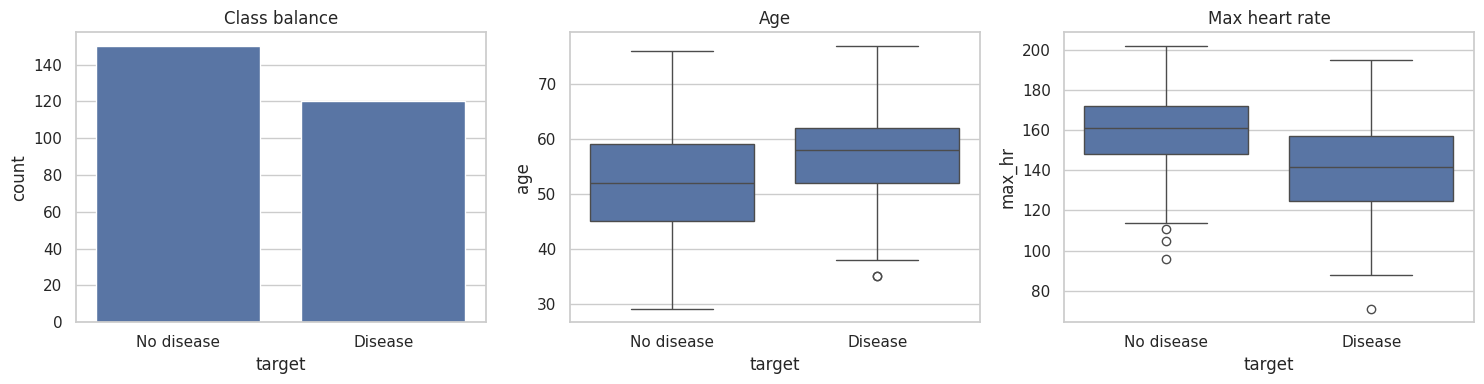

In [5]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
sns.countplot(x="target",data=df,ax=ax[0]); ax[0].set_xticklabels(["No disease","Disease"]); ax[0].set_title("Class balance")
sns.boxplot(x="target",y="age",data=df,ax=ax[1]); ax[1].set_xticklabels(["No disease","Disease"]); ax[1].set_title("Age")
sns.boxplot(x="target",y="max_hr",data=df,ax=ax[2]); ax[2].set_xticklabels(["No disease","Disease"]); ax[2].set_title("Max heart rate")
plt.tight_layout()
plt.show()

In [6]:
# Disease rate (%) by category
for c in ["sex","chest_pain","exang","major_vessels","thal"]:
    print((df.groupby(c)["target"].mean()*100).round(1).rename("% with disease").to_frame().T.to_string(), "\n")

sex                0     1
% with disease  23.0  54.6 

chest_pain         1     2     3     4
% with disease  25.0  16.7  21.5  70.5 

exang              0     1
% with disease  29.8  74.2 

major_vessels      0     1     2     3
% with disease  25.0  65.5  78.8  84.2 

thal               3     6     7
% with disease  21.7  57.1  76.0 



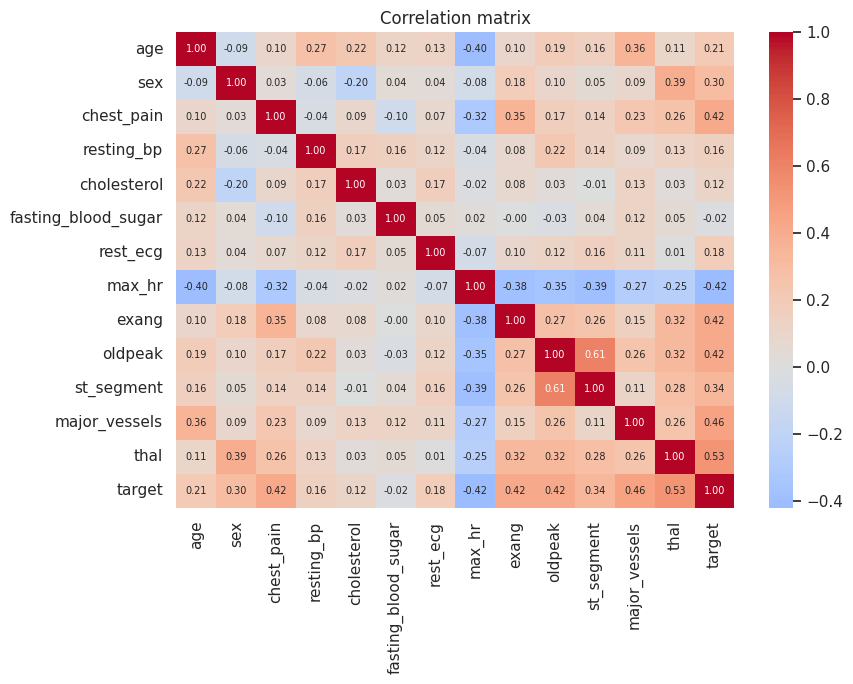

thal                   0.53
major_vessels          0.46
exang                  0.42
oldpeak                0.42
chest_pain             0.42
st_segment             0.34
sex                    0.30
age                    0.21
rest_ecg               0.18
resting_bp             0.16
cholesterol            0.12
fasting_blood_sugar   -0.02
max_hr                -0.42
Name: target, dtype: float64

In [7]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,annot_kws={"size":7})
plt.title("Correlation matrix"); plt.tight_layout()
plt.show()
df.corr()["target"].drop("target").sort_values(ascending=False).round(2)

## 4. Machine learning

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
X=df.drop(columns="target"); y=df["target"]
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
models={"Logistic Regression":make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000)),
        "KNN":make_pipeline(StandardScaler(),KNeighborsClassifier(7)),
        "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42)}
cv=StratifiedKFold(5,shuffle=True,random_state=42)
res=[]
for n,m in models.items():
    s=cross_val_score(m,Xtr,ytr,cv=cv).mean()
    m.fit(Xtr,ytr); res.append((n,round(s,3),round(m.score(Xte,yte),3)))
pd.DataFrame(res,columns=["model","CV accuracy (train)","test accuracy"])

                 model  CV accuracy (train)  test accuracy
0  Logistic Regression                0.819          0.852
1                  KNN                0.833          0.796
2        Random Forest                0.824          0.833

              precision    recall  f1-score   support

  No disease       0.92      0.80      0.86        30
     Disease       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



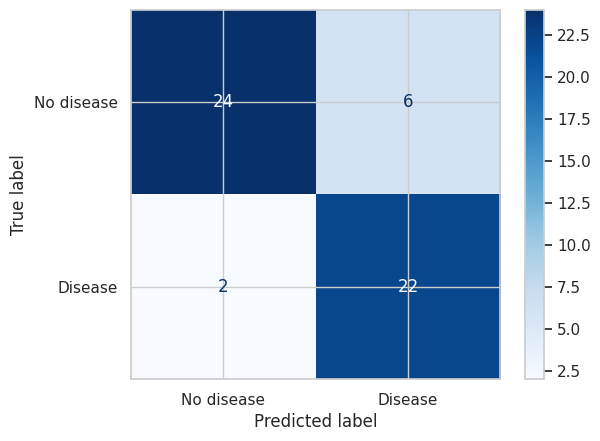

In [9]:
best=models["Logistic Regression"]
pred=best.predict(Xte)
print(classification_report(yte,pred,target_names=["No disease","Disease"]))
ConfusionMatrixDisplay(confusion_matrix(yte,pred),display_labels=["No disease","Disease"]).plot(cmap="Blues")
plt.show()

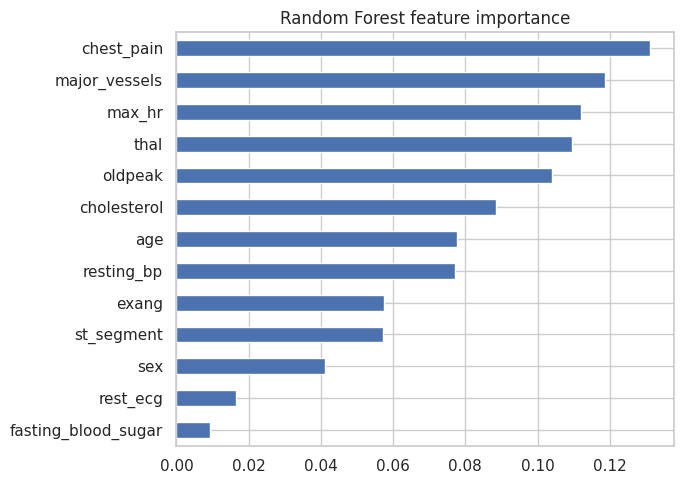

In [10]:
rf=models["Random Forest"]
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values()
imp.plot.barh(figsize=(7,5),title="Random Forest feature importance"); plt.tight_layout()
plt.show()

## 5. Conclusions
- **What matters most:** the features most correlated with heart disease were `thal` (0.53), number of major vessels (0.46), exercise-induced angina, ST depression (`oldpeak`) and chest pain type (about 0.42 each). Max heart rate was negatively related (-0.42): patients who reached a higher heart rate during exercise were less likely to have the disease. Fasting blood sugar had almost no relationship (-0.02).
- **Best model:** Logistic Regression reached **85.2% accuracy** on the test set (81.9% in cross-validation), ahead of Random Forest (83.3%) and KNN (79.6%). On the test set it found **92% of patients who had the disease** (recall), which matters because missing a sick patient is the costly mistake. Its precision for the disease class was 79%.
- **Why the simple model won:** with only 270 patients, a simple model can match or beat a more complex one, which tends to overfit small datasets.
- **Limits:** the dataset is small (270 patients), the test set has only 54 patients, so the accuracy could easily change by several points with another split. This is a learning project and not a medical tool.
- **Next steps:** try a larger dataset, tune the hyperparameters, and check the model on a second hospital's data.